In [4]:
import pandas
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Helper function for visualization

In [ ]:
from astropy.visualization import ImageNormalize, AsinhStretch
from astropy.io import fits
from astropy.visualization import ZScaleInterval

def imshow_zscale_asinh(data, ax=None, cmap="gray", contrast=0.25):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    img = np.array(data, dtype=float)
    img[~np.isfinite(img)] = np.nan

    interval = ZScaleInterval(contrast=contrast)
    vmin, vmax = interval.get_limits(img[np.isfinite(img)])

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch())
    im = ax.imshow(img, origin="lower", cmap=cmap, norm=norm, interpolation="nearest")
    #plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

# Load data

In [10]:
f090_path_1 = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/f090_f200/jw06565-o002_t001_nircam_clear-f090w/jw06565-o002_t001_nircam_clear-f090w_i2d.fits"
f090_path_2 = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/f090_f200/jw06565-o003_t001_nircam_clear-f090w/jw06565-o003_t001_nircam_clear-f090w_i2d.fits'
f090_path_3 = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/f090_f200/jw06565-o005_t002_nircam_clear-f090w/jw06565-o005_t002_nircam_clear-f090w_i2d.fits"

In [11]:
#f200_path = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MAST_2026-02-18T1439/JWST/jw06565-o002_t001_nircam_clear-f200w/jw06565-o002_t001_nircam_clear-f200w_i2d.fits"
#f90 = fits.open(f090_path)
#f200 = fits.open(f200_path)
f090_1 = fits.open(f090_path_1)
f090_2 = fits.open(f090_path_2)
f090_3 = fits.open(f090_path_3)

# Visualize

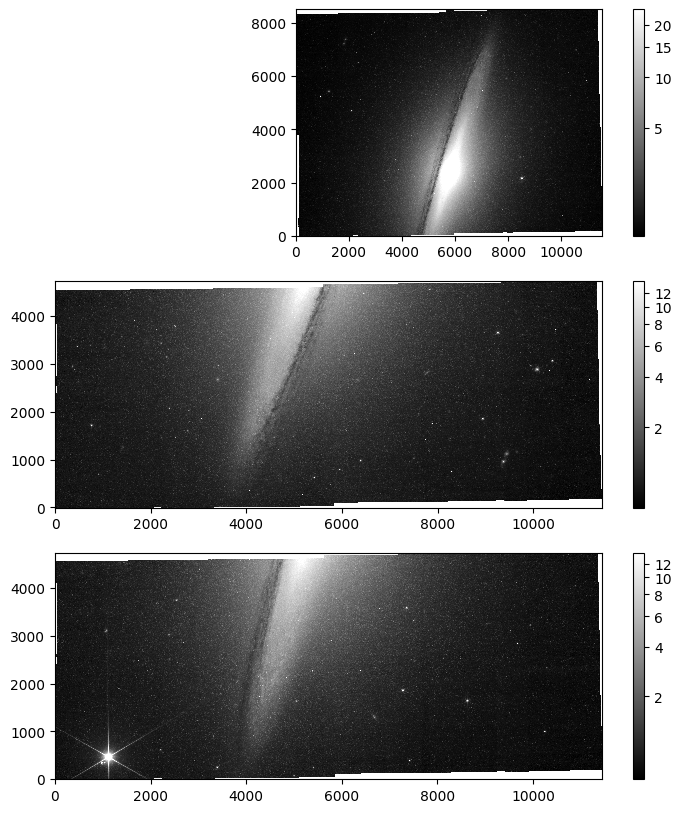

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
imshow_zscale_asinh(f090_1[1].data, ax=ax[0], contrast=0.05)
imshow_zscale_asinh(f090_2[1].data, ax=ax[1], contrast=0.05)
imshow_zscale_asinh(f090_3[1].data, ax=ax[2], contrast=0.05)
plt.show()

# Join images

In [20]:
from reproject.mosaicking import reproject_and_coadd
from reproject.mosaicking import find_optimal_celestial_wcs
from reproject import reproject_exact

# find the optimal WCS and shape for our mosaic
wcs, shape = find_optimal_celestial_wcs(
    [f090_1[1], f090_2[1], f090_3[1]]
)

# reproject and coadd the images
coadd, footprint = reproject_and_coadd([f090_path_1, f090_path_2, f090_path_3], output_projection=wcs, shape_out=shape, reproject_function=reproject_exact, hdu_in=1)

Set DATE-AVG to '2024-06-04T19:44:57.579' from MJD-AVG.
Set DATE-END to '2024-06-04T20:23:53.096' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -34.225446 from OBSGEO-[XYZ].
Set OBSGEO-H to 1715226790.298 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-01-01T16:13:53.353' from MJD-AVG.
Set DATE-END to '2025-01-01T17:00:46.224' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    10.325139 from OBSGEO-[XYZ].
Set OBSGEO-H to 1686172394.952 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-20T19:52:19.342' from MJD-AVG.
Set DATE-END to '2025-05-20T20:08:29.161' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -30.767606 from OBSGEO-[XYZ].
Set OBSGEO-H to 1692635848.326 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-06-04T19:44:57.579' from MJD-AVG.
Set DATE-END to '2024-06-04T20:23:53.096' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -34.225446 from OBSGEO-[XYZ].
Set OBSGEO-H to 1715226790.298 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/Users/m

In [21]:
# save the mosaic to a new FITS file
hdu = fits.PrimaryHDU(coadd, header=wcs.to_header())
hdu.writeto('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/f090_f200/f090_mosaic.fits', overwrite=True)